In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [12]:
files = [
    "cuda_results64.csv",
    "cuda_results128.csv",
    "cuda_results.csv",
    "cuda_results512.csv"
]

df = pd.concat(
    [pd.read_csv(file) for file in files],
    ignore_index=True
)

df.to_csv("combined.csv", index=False)
df.head()

,Type,Size,Blocks,ThreadsPerBlock,ComputationTimeMs,ExecutionTimeMs,DataTransferTimeMs,Throughput,Sorted
0,Cuda Odd-Even,10000,79,64,81.628,82.401,0.102,121314.17,Yes
1,Cuda Odd-Even,100000,782,64,743.315,745.473,0.191,134030.17,Yes
2,Cuda Odd-Even,200000,1563,64,1604.923,1608.728,0.238,124234.54,Yes
3,Cuda Odd-Even,10000,79,64,72.706,73.263,0.076,136403.32,Yes
4,Cuda Odd-Even,100000,782,64,735.854,737.587,0.152,135494.36,Yes


In [23]:
gpu_df = pd.read_csv("cuda_combined.csv")
cpu_df = pd.read_csv("cpu_sequential.csv")

cpu_base = cpu_df[["Size", "ExecutionTimeMs"]].rename(
    columns={"ExecutionTimeMs": "CpuBaselineExecutionTimeMs"}
)

summary_df = (
    gpu_df.groupby(["Type", "Size", "ThreadsPerBlock"], as_index=False)
      .agg(
          Blocks_mean=("Blocks", "mean"),

          ComputationTimeMs_mean=("ComputationTimeMs", "mean"),
          ComputationTimeMs_p95=("ComputationTimeMs", lambda x: x.quantile(0.95)),

          ExecutionTimeMs_mean=("ExecutionTimeMs", "mean"),
          ExecutionTimeMs_p95=("ExecutionTimeMs", lambda x: x.quantile(0.95)),

          DataTransferTimeMs_mean=("DataTransferTimeMs", "mean"),
          DataTransferTimeMs_p95=("DataTransferTimeMs", lambda x: x.quantile(0.95)),

          Throughput_mean=("Throughput", "mean"),
          Throughput_p95=("Throughput", lambda x: x.quantile(0.95)),
      )
      .round(3)
)

summary_df

,Type,Size,ThreadsPerBlock,Blocks_mean,ComputationTimeMs_mean,ComputationTimeMs_p95,ExecutionTimeMs_mean,ExecutionTimeMs_p95,DataTransferTimeMs_mean,DataTransferTimeMs_p95,Throughput_mean,Throughput_p95
0,Cuda Odd-Even,10000,64,79.0,73.851,80.290,74.487,81.030,0.081,0.098,134681.380,141138.142
1,Cuda Odd-Even,10000,128,40.0,81.258,91.511,82.038,92.215,0.088,0.098,123919.032,145688.730
2,Cuda Odd-Even,10000,256,20.0,77.944,106.623,78.714,107.676,0.077,0.105,134123.402,152849.988
3,Cuda Odd-Even,10000,512,10.0,79.074,99.973,79.704,100.706,0.090,0.110,129294.788,148444.340
4,Cuda Odd-Even,100000,64,782.0,754.241,772.953,756.195,775.136,0.168,0.188,132201.655,135274.732
5,Cuda Odd-Even,100000,128,391.0,828.870,880.510,830.678,882.464,0.183,0.212,120611.742,128142.980
6,Cuda Odd-Even,100000,256,196.0,804.132,875.163,805.941,876.956,0.164,0.179,124810.360,136807.137
7,Cuda Odd-Even,100000,512,98.0,764.857,790.670,766.801,792.716,0.220,0.266,130509.578,137284.173
8,Cuda Odd-Even,200000,64,1563.0,1634.630,1682.704,1637.926,1685.930,0.282,0.306,122091.330,125022.864
9,Cuda Odd-Even,200000,128,782.0,1608.880,1682.520,1611.847,1685.388,0.258,0.286,124234.157,131695.173


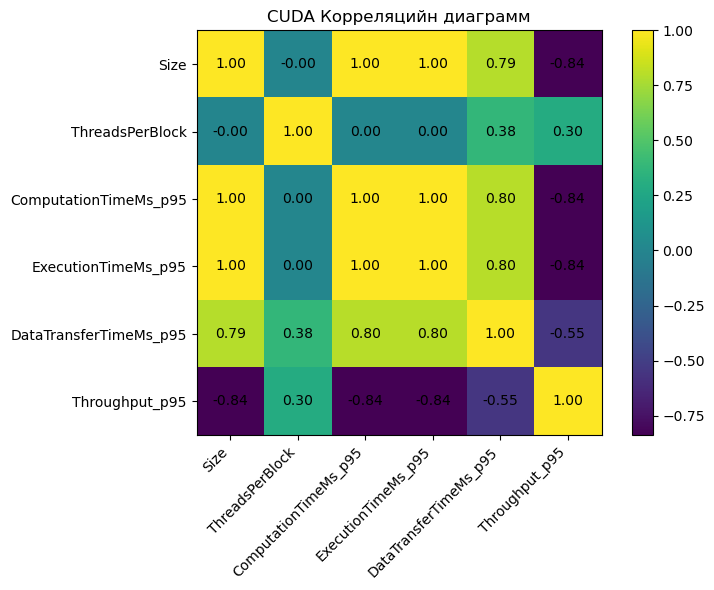

In [35]:
corr_data = summary_df[
    [
        "Size",
        "ThreadsPerBlock",
        "ComputationTimeMs_p95",
        "ExecutionTimeMs_p95",
        "DataTransferTimeMs_p95",
        "Throughput_p95"
    ]
]

corr_matrix = corr_data.corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

# put correlation values inside cells
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("CUDA Корреляцийн диаграмм")
plt.tight_layout()

plt.savefig("../images/cuda_correlation_diagram.png", dpi=600, bbox_inches="tight")

plt.show()

In [31]:
result_df = summary_df.merge(cpu_base, on="Size", how="left")
result_df["Speedup_mean"] = (
    result_df["CpuBaselineExecutionTimeMs"] / result_df["ExecutionTimeMs_mean"]
)
result_df["Speedup_p95"] = (
    result_df["CpuBaselineExecutionTimeMs"] / result_df["ExecutionTimeMs_p95"]
)
result_df["TotalCudaThreads"] = (
    result_df["Blocks_mean"] * result_df["ThreadsPerBlock"]
)
result_df["Efficiency_mean"] = (
    result_df["Speedup_mean"] / result_df["TotalCudaThreads"]
)

result_df["Efficiency_p95"] = (
    result_df["Speedup_p95"] / result_df["TotalCudaThreads"]
)
result_df["EfficiencyPercent_mean"] = result_df["Efficiency_mean"] * 100
result_df["EfficiencyPercent_p95"] = result_df["Efficiency_p95"] * 100
result_df = result_df.round(6)
result_df

,Type,Size,ThreadsPerBlock,Blocks_mean,ComputationTimeMs_mean,ComputationTimeMs_p95,ExecutionTimeMs_mean,ExecutionTimeMs_p95,DataTransferTimeMs_mean,DataTransferTimeMs_p95,Throughput_mean,Throughput_p95,CpuBaselineExecutionTimeMs,Speedup_mean,Speedup_p95,TotalCudaThreads,Efficiency_mean,Efficiency_p95,EfficiencyPercent_mean,EfficiencyPercent_p95
0,Cuda Odd-Even,10000,64,79.0,73.851,80.290,74.487,81.030,0.081,0.098,134681.380,141138.142,272.593,3.659605,3.364100,5056.0,0.000724,0.000665,0.072381,0.066537
1,Cuda Odd-Even,10000,128,40.0,81.258,91.511,82.038,92.215,0.088,0.098,123919.032,145688.730,272.593,3.322765,2.956059,5120.0,0.000649,0.000577,0.064898,0.057736
2,Cuda Odd-Even,10000,256,20.0,77.944,106.623,78.714,107.676,0.077,0.105,134123.402,152849.988,272.593,3.463082,2.531604,5120.0,0.000676,0.000494,0.067638,0.049445
3,Cuda Odd-Even,10000,512,10.0,79.074,99.973,79.704,100.706,0.090,0.110,129294.788,148444.340,272.593,3.420067,2.706820,5120.0,0.000668,0.000529,0.066798,0.052868
4,Cuda Odd-Even,100000,64,782.0,754.241,772.953,756.195,775.136,0.168,0.188,132201.655,135274.732,31346.052,41.452340,40.439422,50048.0,0.000828,0.000808,0.082825,0.080801
5,Cuda Odd-Even,100000,128,391.0,828.870,880.510,830.678,882.464,0.183,0.212,120611.742,128142.980,31346.052,37.735503,35.521055,50048.0,0.000754,0.000710,0.075399,0.070974
6,Cuda Odd-Even,100000,256,196.0,804.132,875.163,805.941,876.956,0.164,0.179,124810.360,136807.137,31346.052,38.893730,35.744156,50176.0,0.000775,0.000712,0.077515,0.071238
7,Cuda Odd-Even,100000,512,98.0,764.857,790.670,766.801,792.716,0.220,0.266,130509.578,137284.173,31346.052,40.878992,39.542600,50176.0,0.000815,0.000788,0.081471,0.078808
8,Cuda Odd-Even,200000,64,1563.0,1634.630,1682.704,1637.926,1685.930,0.282,0.306,122091.330,125022.864,156084.264,95.293844,92.580513,100032.0,0.000953,0.000926,0.095263,0.092551
9,Cuda Odd-Even,200000,128,782.0,1608.880,1682.520,1611.847,1685.388,0.258,0.286,124234.157,131695.173,156084.264,96.835657,92.610286,100096.0,0.000967,0.000925,0.096743,0.092521


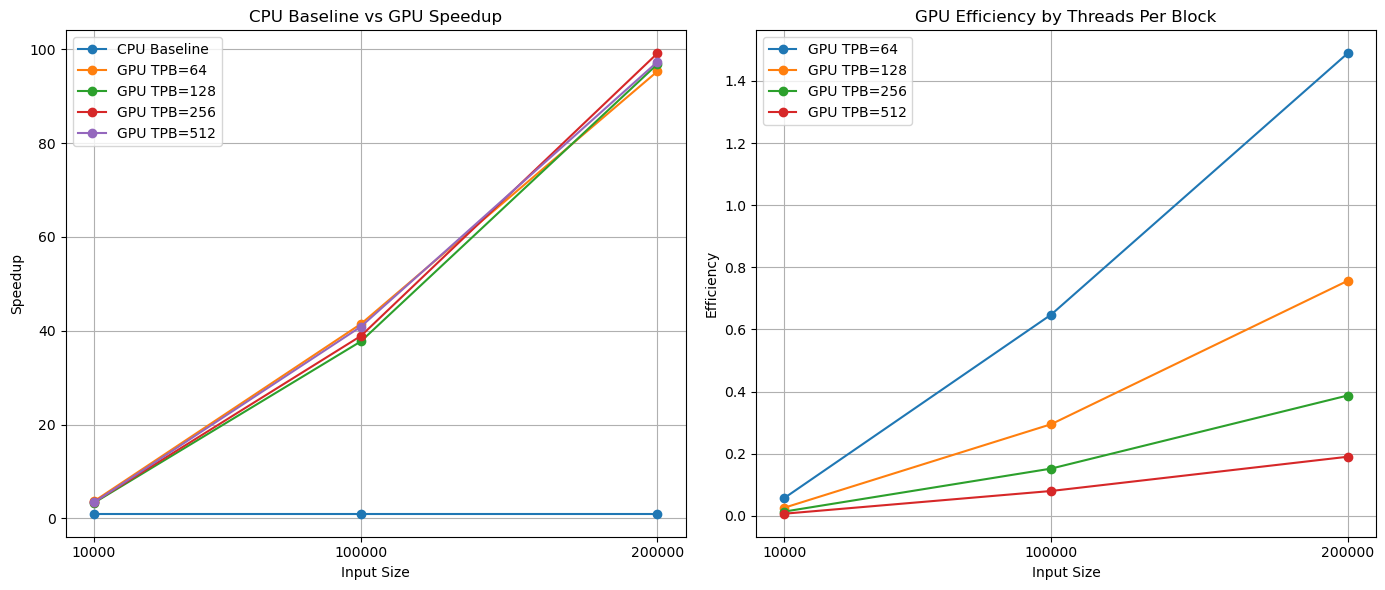

In [33]:
plot_df = result_df.sort_values(["ThreadsPerBlock", "Size"])

sizes = sorted(plot_df["Size"].unique())

# Efficiency calculation
# Option 1: efficiency by threads per block
plot_df["Efficiency_mean"] = plot_df["Speedup_mean"] / plot_df["ThreadsPerBlock"]

# If you have Blocks column, this is better:
# plot_df["TotalThreads"] = plot_df["Blocks"] * plot_df["ThreadsPerBlock"]
# plot_df["Efficiency_mean"] = plot_df["Speedup_mean"] / plot_df["TotalThreads"]

plt.figure(figsize=(14, 6))

# -----------------------------
# Graph 1: Speedup
# -----------------------------
plt.subplot(1, 2, 1)

plt.plot(sizes, [1.0] * len(sizes), marker='o', label="CPU Baseline")

for tpb in sorted(plot_df["ThreadsPerBlock"].unique()):
    subset = plot_df[plot_df["ThreadsPerBlock"] == tpb].sort_values("Size")
    plt.plot(
        subset["Size"],
        subset["Speedup_mean"],
        marker='o',
        label=f"GPU TPB={tpb}"
    )

plt.xlabel("Input Size")
plt.ylabel("Speedup")
plt.title("CPU Baseline vs GPU Speedup")
plt.xticks(sizes, [str(s) for s in sizes])
plt.legend()
plt.grid(True)

# -----------------------------
# Graph 2: Efficiency
# -----------------------------
plt.subplot(1, 2, 2)

for tpb in sorted(plot_df["ThreadsPerBlock"].unique()):
    subset = plot_df[plot_df["ThreadsPerBlock"] == tpb].sort_values("Size")
    plt.plot(
        subset["Size"],
        subset["Efficiency_mean"],
        marker='o',
        label=f"GPU TPB={tpb}"
    )

plt.xlabel("Input Size")
plt.ylabel("Efficiency")
plt.title("GPU Efficiency by Threads Per Block")
plt.xticks(sizes, [str(s) for s in sizes])
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()